In [ ]:
!nvidia-smi  # to check if the system supports GPU

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
!pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.8 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
YOLO('yolov8n.pt')
print("YOLOv8 installed successfully!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8 installed successfully!


To set up google drive, in order to save model and files

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


ValueError: mount failed

In [ ]:
!pip install kaggle

In [ ]:
#file upload
from google.colab import files
files.upload()

In [ ]:
#for this you require the kaggle API to be uploaded in the same folder, use the below cell code to upload it.
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Downloading datasets

In [ ]:
# 1️⃣ Helmet dataset
!kaggle datasets download -d andrewmvd/hard-hat-detection -p /content/data --unzip

# 2️⃣ Mask dataset
!kaggle datasets download -d andrewmvd/face-mask-detection -p /content/data --unzip


In [ ]:

!kaggle datasets download -d shivanandverma/helmet-and-vest-detection-dataset -p /content/data
!unzip /content/data/helmet-and-vest-detection-dataset.zip -d /content/data/helmet-and-vest-detection

It converts annotation files from Pascal VOC (XML format) into YOLO format (TXT), which YOLO models require.

In [ ]:
import os
import xml.etree.ElementTree as ET

# paths
xml_folder = "/content/data/annotations"
output_folder = "/content/PPE_Combined/data/labels"

# class list
classes = ["helmet", "no_helmet","suit","no_suit"]

os.makedirs(output_folder, exist_ok=True)

for xml_file in os.listdir(xml_folder):
    if not xml_file.endswith(".xml"):
        continue
    tree = ET.parse(os.path.join(xml_folder, xml_file))
    root = tree.getroot()
    image_name = root.find("filename").text.replace(".jpg", "")

    label_path = os.path.join(output_folder, f"{image_name}.txt")
    with open(label_path, "w") as f:
        for obj in root.findall("object"):
            cls = obj.find("name").text
            if cls not in classes:
                continue
            cls_id = classes.index(cls)
            xml_box = obj.find("bndbox")
            x_min = float(xml_box.find("xmin").text)
            y_min = float(xml_box.find("ymin").text)
            x_max = float(xml_box.find("xmax").text)
            y_max = float(xml_box.find("ymax").text)

            # Convert to YOLO format
            x_center = (x_min + x_max) / 2.0
            y_center = (y_min + y_max) / 2.0
            width = x_max - x_min
            height = y_max - y_min

            # normalize
            image_width = float(root.find("size/width").text)
            image_height = float(root.find("size/height").text)
            x_center /= image_width
            y_center /= image_height
            width /= image_width
            height /= image_height

            f.write(f"{cls_id} {x_center} {y_center} {width} {height}\n")

print("XML to YOLO TXT conversion complete.")


In [ ]:
import os
import random
import shutil
import xml.etree.ElementTree as ET
from tqdm import tqdm

# Base paths
base_dir = "/content/data"
combined_dir = "/content/PPE_Combined"

# Ensure combined directory exists
os.makedirs(combined_dir, exist_ok=True)

In [ ]:
# Class list
classes = ['helmet', 'no_helmet', 'suit', 'no_suit']

# Split ratios
train_split = 0.7
valid_split = 0.2
test_split = 0.1


It:

1. Cleans old folders (so no leftover data)

2. Merges multiple datasets (helmet, mask, vest) into one combined dataset

3. Converts all XML labels (Pascal VOC format) to YOLO TXT format, if any left

4. Splits data into train, validation, and test sets

5. Moves files into the correct folders

In [ ]:
# TO move files
def move_files(files, dest):
    for f in tqdm(files, desc=f"Moving to {dest}"):
        # Construct source paths
        src_img = os.path.join(combined_dir, "train", "images", f)
        src_lbl = os.path.join(combined_dir, "train", "labels", os.path.splitext(f)[0] + ".txt")

        # Construct destination paths
        dest_img = os.path.join(combined_dir, dest, "images", f)
        dest_lbl = os.path.join(combined_dir, dest, "labels", os.path.splitext(f)[0] + ".txt")

        # Move image and label if they exist
        if os.path.exists(src_img):
            shutil.move(src_img, dest_img)
        if os.path.exists(src_lbl):
            shutil.move(src_lbl, dest_lbl)

#  Clean Old Folders
for split in ["train", "valid", "test"]:
    img_dir = os.path.join(combined_dir, split, "images")
    lbl_dir = os.path.join(combined_dir, split, "labels")
    if os.path.exists(img_dir):
        shutil.rmtree(img_dir)
    if os.path.exists(lbl_dir):
        shutil.rmtree(lbl_dir)
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(lbl_dir, exist_ok=True)

#Merge and Convert
source_folders = [
    "hard-hat-detection",
    "face-mask-detection",
    "helmet-and-vest-detection"
]

for folder in source_folders:
    src_path = os.path.join(base_dir, folder)
    for root, dirs, files in os.walk(src_path):
        for file in files:
            if file.endswith((".jpg", ".png", ".jpeg")):
                shutil.copy(os.path.join(root, file), os.path.join(combined_dir, "train", "images"))
            elif file.endswith(".xml"):
                xml_file = os.path.join(root, file)
                tree = ET.parse(xml_file)
                root_xml = tree.getroot()
                img_w = int(root_xml.find("size/width").text)
                img_h = int(root_xml.find("size/height").text)
                txt_filename = os.path.join(combined_dir, "train", "labels", file.replace(".xml", ".txt"))
                with open(txt_filename, "w") as f:
                    for obj in root_xml.findall("object"):
                        cls_name = obj.find("name").text
                        if cls_name not in classes:
                            continue
                        cls_id = classes.index(cls_name)
                        bbox = obj.find("bndbox")
                        xmin = int(bbox.find("xmin").text)
                        ymin = int(bbox.find("ymin").text)
                        xmax = int(bbox.find("xmax").text)
                        ymax = int(bbox.find("ymax").text)
                        x_center = (xmin + xmax) / 2 / img_w
                        y_center = (ymin + ymax) / 2 / img_h
                        width = (xmax - xmin) / img_w
                        height = (ymax - ymin) / img_h
                        f.write(f"{cls_id} {x_center} {y_center} {width} {height}\n")
            elif file.endswith(".txt"):
                 # Handle .txt label files from the helmet and vest dataset
                 if folder == "helmet-and-vest-detection":
                     src_lbl_path = os.path.join(root, file)
                     dest_lbl_path = os.path.join(combined_dir, "train", "labels", file)
                     # Append the content of the source label file to the destination label file
                     with open(src_lbl_path, 'r') as src_file, open(dest_lbl_path, 'a') as dest_file:
                         dest_file.write(src_file.read())
                 else:
                    shutil.copy(os.path.join(root, file), os.path.join(combined_dir, "train", "labels"))


# Reshuffle & Split
all_images = os.listdir(os.path.join(combined_dir, "train", "images"))
random.shuffle(all_images)

total = len(all_images)
train_count = int(train_split * total)
valid_count = int(valid_split * total)
test_count = total - train_count - valid_count

train_files = all_images[:train_count]
valid_files = all_images[train_count:train_count + valid_count]
test_files = all_images[train_count + valid_count:]

# Move valid/test files
move_files(valid_files, "valid")
move_files(test_files, "test")

print(f" Split complete!")
print(f"Train: {len(os.listdir(os.path.join(combined_dir, 'train', 'images')))}")
print(f"Valid: {len(os.listdir(os.path.join(combined_dir, 'valid', 'images')))}")
print(f"Test: {len(os.listdir(os.path.join(combined_dir, 'test', 'images')))}")

data.yaml file: it tells the YOLO model where the dataset is and what are the classes and what they mean.

Here we have 4 classes: helmet, no helmet, suit, no suit

In [ ]:
yaml_content = """train: /content/PPE_Combined/train/images
val: /content/PPE_Combined/valid/images
test: /content/PPE_Combined/test/images

nc: 4
names: ['helmet', 'no_helmet', 'suit', 'no_suit']
"""

with open("/content/PPE_Combined/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml created successfully!")


Verify if everything is at the correct position

In [ ]:
!ls /content/PPE_Combined/train/labels | head


In [ ]:
!cat /content/PPE_Combined/train/labels/bike_helmet_0.txt


This is to train the model. Commented since the model is saved and we can just load it

In [ ]:
# !yolo task=detect mode=train model=yolov8m.pt data=/content/PPE_Combined/data.yaml epochs=100 imgsz=640 batch=16 augment=True lr0=0.001



Saving the model to drive

In [ ]:
# !cp runs/detect/train/weights/best.pt /content/drive/MyDrive/ColabNotebooks/best.pt

Loading model from the drive

In [ ]:
from ultralytics import YOLO
model = YOLO('/content/drive/MyDrive/ColabNotebooks/best.pt')


Predictions

In [ ]:
results = model.predict(source='/content/PPE_Combined/test/images',save=True,imgsz=640,conf=0.3)

In [ ]:
import os
from IPython.display import Image, display

# Folder where YOLO saved results
result_folder = '/content/runs/detect/predict/'

# Display all output images one by one
for img_name in os.listdir(result_folder):
    if img_name.lower().endswith(('.jpg', '.png', '.jpeg')):
        display(Image(filename=os.path.join(result_folder, img_name)))


Stats of the model. mAP50 refers to accuracy

In [ ]:
!yolo task=detect mode=val \
model="/content/drive/MyDrive/ColabNotebooks/best.pt" \
data="/content/PPE_Combined/data.yaml"


In [ ]:
import os

labels_dir = "/content/PPE_Combined/train/labels"
counts = {"helmet": 0, "no_helmet": 0, "suit": 0, "no_suit": 0}

for file in os.listdir(labels_dir):
    if not file.endswith(".txt"):
        continue
    with open(os.path.join(labels_dir, file)) as f:
        for line in f:
            cls_id = int(line.split()[0])
            if cls_id == 0: counts["helmet"] += 1
            elif cls_id == 1: counts["no_helmet"] += 1
            elif cls_id == 2: counts["suit"] += 1
            elif cls_id == 3: counts["no_suit"] += 1

print(counts)


In [ ]:
!yolo task=detect mode=train \
model=yolov8m.pt \
data=/content/PPE_Combined/data.yaml \
epochs=150 \
imgsz=960 \
batch=8 \
lr0=0.0008 \
optimizer=SGD \
momentum=0.937 \
hsv_h=0.015 hsv_s=0.7 hsv_v=0.4 \
degrees=10 translate=0.1 scale=0.8 shear=2 \
flipud=0.5 fliplr=0.5 mosaic=1.0 mixup=0.3 copy_paste=0.3 \
auto_augment=ta_wide close_mosaic=15


In [ ]:
!cp /content/runs/detect/train/weights/best.pt /content/drive/MyDrive/


In [ ]:
!cp -r /content/PPE_Combined /content/drive/MyDrive/


In [ ]:
!pip install albumentations==1.4.4


In [ ]:
!rm -rf /content/PPE_Combined
!ln -s /content/drive/MyDrive/PPE_Combined /content/PPE_Combined


In [ ]:
!ls /content/PPE_Combined/train/labels | head


In [ ]:
# ===========================
# 🚀 PPE Fine-tune to 90%+ Accuracy
# ===========================
from google.colab import drive
drive.mount('/content/drive')

import os
import random
import shutil
import cv2
import albumentations as A
from tqdm import tqdm
from ultralytics import YOLO

# --- Link Dataset ---
if not os.path.exists("/content/PPE_Combined"):
    !ln -s /content/drive/MyDrive/PPE_Combined /content/PPE_Combined

# --- Define paths ---
img_dir = "/content/PPE_Combined/train/images"
lbl_dir = "/content/PPE_Combined/train/labels"
aug_img_dir = "/content/PPE_Combined/train/images_aug"
aug_lbl_dir = "/content/PPE_Combined/train/labels_aug"

os.makedirs(aug_img_dir, exist_ok=True)
os.makedirs(aug_lbl_dir, exist_ok=True)

# --- Classes ---
target_classes = ["helmet", "suit"]
class_map = {"helmet": 0, "no_helmet": 1, "no_suit": 2, "suit": 3}

# --- Augmentation settings ---
transform = A.Compose([
    A.RandomBrightnessContrast(p=0.3),
    A.HueSaturationValue(p=0.3),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5),
    A.Affine(scale=(0.9, 1.1), translate_percent=(0.05, 0.1), p=0.5),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# --- Augment minority classes (helmet, suit) ---
for lbl_file in tqdm(os.listdir(lbl_dir), desc="Augmenting helmet/suit"):
    if not lbl_file.endswith(".txt"): continue
    with open(os.path.join(lbl_dir, lbl_file)) as f:
        lines = f.readlines()
    has_target = any(str(class_map[c]) in line for c in target_classes for line in lines)
    if not has_target: continue

    img_name = lbl_file.replace(".txt", ".jpg")
    img_path = os.path.join(img_dir, img_name)
    if not os.path.exists(img_path): continue

    image = cv2.imread(img_path)
    bboxes, cls = [], []
    for line in lines:
        vals = line.strip().split()
        if len(vals) != 5: continue
        cls_id, x, y, bw, bh = map(float, vals)
        bboxes.append([x, y, bw, bh])
        cls.append(int(cls_id))

    # 2x augmentation
    for i in range(2):
        augmented = transform(image=image, bboxes=bboxes, class_labels=cls)
        aug_img, aug_bboxes, aug_cls = augmented["image"], augmented["bboxes"], augmented["class_labels"]
        new_name = f"{os.path.splitext(img_name)[0]}_aug{i}.jpg"
        new_lbl = f"{os.path.splitext(lbl_file)[0]}_aug{i}.txt"
        cv2.imwrite(os.path.join(aug_img_dir, new_name), aug_img)
        with open(os.path.join(aug_lbl_dir, new_lbl), "w") as f:
            for j, (x, y, bw, bh) in enumerate(aug_bboxes):
                f.write(f"{aug_cls[j]} {x:.6f} {y:.6f} {bw:.6f} {bh:.6f}\n")

# --- Merge augmented data ---
!cp /content/PPE_Combined/train/images_aug/* /content/PPE_Combined/train/images/
!cp /content/PPE_Combined/train/labels_aug/* /content/PPE_Combined/train/labels/

print("✅ Augmentation completed and merged successfully.")

# --- Fine-tune model ---
!yolo train \
model=/content/drive/MyDrive/runs/detect/train2/weights/best.pt \
data=/content/PPE_Combined/data.yaml \
epochs=30 imgsz=960 batch=8 \
lr0=0.00035 optimizer=AdamW momentum=0.937 \
freeze=10 fl_gamma=2.0 \
hsv_h=0.015 hsv_s=0.5 hsv_v=0.4 \
mosaic=0.6 mixup=0.05 translate=0.1 scale=0.8 shear=0.1 \
copy_paste=0.4 \
patience=10 cos_lr=True rect=True cache=True

# --- Validate model ---
!yolo val model=/content/runs/detect/train/weights/best.pt data=/content/PPE_Combined/data.yaml conf=0.25 iou=0.45


In [ ]:

!yolo train \
model=/content/drive/MyDrive/runs/detect/train2/weights/best.pt \
data=/content/PPE_Combined/data.yaml \
epochs=30 imgsz=960 batch=8 \
lr0=0.00035 optimizer=AdamW momentum=0.937 \
freeze=10 \
hsv_h=0.015 hsv_s=0.5 hsv_v=0.4 \
mosaic=0.6 mixup=0.05 translate=0.1 scale=0.8 shear=0.1 \
copy_paste=0.4 \
patience=10 cos_lr=True rect=True cache=True


In [ ]:
# Search for best.pt anywhere inside your Drive (may take a few seconds)
!find /content/drive/MyDrive -type f -name "best.pt" -print || true


In [ ]:
%%bash
# ✅ Check if your best.pt exists, else use yolov8m.pt

MODEL_PATH="/content/drive/MyDrive/ColabNotebooks/best.pt"

if [ -f "$MODEL_PATH" ]; then
  echo "✅ Using MODEL_PATH: $MODEL_PATH"
else
  echo "⚠️ MODEL_PATH not found at $MODEL_PATH"
  echo "⬇️ Falling back to official pretrained yolov8m.pt"
  MODEL_PATH="yolov8m.pt"
  # Download YOLOv8m if needed
  yolo detect train model=yolov8m.pt data=coco8.yaml epochs=1 || true
fi


In [ ]:
!ln -sf /content/drive/MyDrive/PPE_Combined /content/PPE_Combined


In [ ]:
!ls /content/PPE_Combined/data.yaml


In [ ]:
!yolo train \
model=/content/drive/MyDrive/ColabNotebooks/best.pt \
data=/content/PPE_Combined/data.yaml \
epochs=30 imgsz=960 batch=8 \
lr0=0.00035 optimizer=AdamW momentum=0.937 \
freeze=10 \
hsv_h=0.015 hsv_s=0.5 hsv_v=0.4 \
mosaic=0.6 mixup=0.05 translate=0.1 scale=0.8 shear=0.1 \
copy_paste=0.4 \
patience=10 cos_lr=True rect=True cache=True


In [ ]:
import os
import cv2
import albumentations as A
from tqdm import tqdm

# Directories
img_dir = "/content/drive/MyDrive/PPE_Combined/train/images"
lbl_dir = "/content/drive/MyDrive/PPE_Combined/train/labels"

aug_img_dir = "/content/drive/MyDrive/PPE_Combined/train/images_aug4"
aug_lbl_dir = "/content/drive/MyDrive/PPE_Combined/train/labels_aug4"
os.makedirs(aug_img_dir, exist_ok=True)
os.makedirs(aug_lbl_dir, exist_ok=True)

# Target classes and their IDs
target_classes = ["helmet", "suit"]
class_map = {"helmet": 0, "no_helmet": 1, "suit": 2, "no_suit": 3}

# Augmentation pipeline with padding
transform = A.Compose([
    A.PadIfNeeded(min_height=1024, min_width=1024, border_mode=cv2.BORDER_CONSTANT, value=0, p=1.0), # Add padding
    A.RandomBrightnessContrast(p=0.3),
    A.HueSaturationValue(p=0.3),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5),
    A.Affine(scale=(0.9, 1.1), translate_percent=(0.05, 0.1), p=0.5),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# Apply 4 augmentations for helmet/suit images
for lbl_file in tqdm(os.listdir(lbl_dir), desc="4x augmenting helmet/suit"):
    if not lbl_file.endswith(".txt"):
        continue

    with open(os.path.join(lbl_dir, lbl_file)) as f:
        lines = f.readlines()

    # check if this image contains helmet or suit
    has_target = any(str(class_map[c]) in line for c in target_classes for line in lines)
    if not has_target:
        continue

    img_name = lbl_file.replace(".txt", ".jpg")
    img_path = os.path.join(img_dir, img_name)
    if not os.path.exists(img_path):
        continue

    image = cv2.imread(img_path)
    if image is None:
        continue

    bboxes, cls = [], []
    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        cls_id, x, y, w, h = map(float, parts)
        bboxes.append([x, y, w, h])
        cls.append(int(cls_id))

    for i in range(4):  # four augmented copies
        try:
            augmented = transform(image=image, bboxes=bboxes, class_labels=cls)
            aug_img = augmented["image"]
            aug_bboxes = augmented["bboxes"]
            aug_cls = augmented["class_labels"]

            # Refined clipping logic
            clipped_bboxes = []
            for bbox in aug_bboxes:
                x_center, y_center, width, height = bbox
                x_min = x_center - width/2
                y_min = y_center - height/2
                x_max = x_center + width/2
                y_max = y_center + height/2

                # Clip coordinates to be within [0, 1]
                x_min = max(0.0, min(1.0, x_min))
                y_min = max(0.0, min(1.0, y_min))
                x_max = max(0.0, min(1.0, x_max))
                y_max = max(0.0, min(1.0, y_max))

                # Recalculate center and width/height after clipping
                new_x_center = (x_min + x_max) / 2
                new_y_center = (y_min + y_max) / 2
                new_width = x_max - x_min
                new_height = y_max - y_min

                clipped_bboxes.append([new_x_center, new_y_center, new_width, new_height])


            new_img = f"{os.path.splitext(img_name)[0]}_aug4_{i}.jpg"
            new_lbl = f"{os.path.splitext(lbl_file)[0]}_aug4_{i}.txt"

            cv2.imwrite(os.path.join(aug_img_dir, new_img), aug_img)
            with open(os.path.join(aug_lbl_dir, new_lbl), "w") as f:
                for j, (x, y, w, h) in enumerate(clipped_bboxes):
                    f.write(f"{aug_cls[j]} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")
        except ValueError:
            # Just skip any extreme outlier augmentations
            continue

In [ ]:
!cp /content/drive/MyDrive/PPE_Combined/train/images_aug4/* /content/drive/MyDrive/PPE_Combined/train/images/
!cp /content/drive/MyDrive/PPE_Combined/train/labels_aug4/* /content/drive/MyDrive/PPE_Combined/train/labels/


In [ ]:
from collections import Counter

class_names = ['helmet', 'no_helmet', 'suit', 'no_suit']
counts = Counter()

for file in os.listdir(lbl_dir):
    if not file.endswith(".txt"):
        continue
    with open(os.path.join(lbl_dir, file)) as f:
        for line in f:
            cls = line.strip().split()[0]
            counts[cls] += 1

print("\n📊 Class-wise distribution:")
for i, name in enumerate(class_names):
    print(f"{name:<10}: {counts.get(str(i), 0)}")


In [ ]:
import os
import cv2
import albumentations as A
from tqdm import tqdm

# Paths
img_dir = "/content/drive/MyDrive/PPE_Combined/train/images"
lbl_dir = "/content/drive/MyDrive/PPE_Combined/train/labels"

aug_img_dir = "/content/drive/MyDrive/PPE_Combined/train/images_aug_final"
aug_lbl_dir = "/content/drive/MyDrive/PPE_Combined/train/labels_aug_final"
os.makedirs(aug_img_dir, exist_ok=True)
os.makedirs(aug_lbl_dir, exist_ok=True)

# ✅ Correct class mapping (suit before no_suit)
class_names = ['helmet', 'no_helmet', 'suit', 'no_suit']
class_map = {name: idx for idx, name in enumerate(class_names)}

# Only augment helmet and suit (underrepresented)
target_classes = ["helmet", "suit"]

# Augmentation pipeline (mild)
transform = A.Compose([
    A.RandomBrightnessContrast(p=0.2),
    A.HueSaturationValue(p=0.2),
    A.HorizontalFlip(p=0.4),
    A.Rotate(limit=8, p=0.4),
    A.Affine(scale=(0.95, 1.05), translate_percent=(0.03, 0.08), p=0.4),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# Light 2× augmentation
for lbl_file in tqdm(os.listdir(lbl_dir), desc="Light 2x augment helmet/suit"):
    if not lbl_file.endswith(".txt"):
        continue

    with open(os.path.join(lbl_dir, lbl_file)) as f:
        lines = f.readlines()

    # Check if image has helmet or suit
    has_target = any(str(class_map[c]) in line for c in target_classes for line in lines)
    if not has_target:
        continue

    img_name = lbl_file.replace(".txt", ".jpg")
    img_path = os.path.join(img_dir, img_name)
    if not os.path.exists(img_path):
        continue

    image = cv2.imread(img_path)
    if image is None:
        continue

    bboxes, cls = [], []
    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        cls_id, x, y, w, h = map(float, parts)
        bboxes.append([x, y, w, h])
        cls.append(int(cls_id))

    for i in range(2):  # 2 new augmentations each
        try:
            augmented = transform(image=image, bboxes=bboxes, class_labels=cls)
            aug_img, aug_bboxes, aug_cls = augmented["image"], augmented["bboxes"], augmented["class_labels"]

            # ✨ Clip coords to [0,1]
            clipped = []
            for (x, y, w, h) in aug_bboxes:
                x = max(0, min(1, x))
                y = max(0, min(1, y))
                w = max(0, min(1, w))
                h = max(0, min(1, h))
                clipped.append([x, y, w, h])

            new_img = f"{os.path.splitext(img_name)[0]}_augfinal_{i}.jpg"
            new_lbl = f"{os.path.splitext(lbl_file)[0]}_augfinal_{i}.txt"

            cv2.imwrite(os.path.join(aug_img_dir, new_img), aug_img)
            with open(os.path.join(aug_lbl_dir, new_lbl), "w") as f:
                for j, (x, y, w, h) in enumerate(clipped):
                    f.write(f"{aug_cls[j]} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")
        except ValueError:
            continue

print("✅ Light augmentation completed successfully with correct class order.")


In [ ]:
import os
from collections import Counter

folders = [
    "/content/drive/MyDrive/PPE_Combined/train/labels_aug",
    "/content/drive/MyDrive/PPE_Combined/train/labels_aug4"
]
class_names = ['helmet', 'no_helmet', 'suit', 'no_suit']

for folder in folders:
    counts = Counter()
    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        continue

    for f in os.listdir(folder):
        if f.endswith(".txt"):
            with open(os.path.join(folder, f)) as file:
                for line in file:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        try:
                            cls_id = int(float(parts[0]))
                            counts[cls_id] += 1
                        except ValueError:
                            continue

    total = sum(counts.values())
    print(f"\n📂 Folder: {folder}")
    print("Class-wise counts:")
    for i, name in enumerate(class_names):
        print(f"  {name:<10}: {counts[i]}")
    print(f"📦 Total labels: {total}")


In [ ]:
import os, shutil
from tqdm import tqdm

src_lbl = "/content/drive/MyDrive/PPE_Combined/train/labels_aug4"
src_img = "/content/drive/MyDrive/PPE_Combined/train/images_aug4"
dest_lbl = "/content/drive/MyDrive/PPE_Combined/train/labels"
dest_img = "/content/drive/MyDrive/PPE_Combined/train/images"

os.makedirs(dest_lbl, exist_ok=True)
os.makedirs(dest_img, exist_ok=True)

for f in tqdm(os.listdir(src_lbl), desc="Copying helmet/suit augmentations"):
    if not f.endswith(".txt"):
        continue
    with open(os.path.join(src_lbl, f)) as file:
        content = file.read()
        if content.startswith("0") or content.startswith("2"):
            img_file = f.replace(".txt", ".jpg")
            if os.path.exists(os.path.join(src_img, img_file)):
                shutil.copy(os.path.join(src_img, img_file), dest_img)
            shutil.copy(os.path.join(src_lbl, f), dest_lbl)


In [ ]:
from collections import Counter
lbl_dir = "/content/drive/MyDrive/PPE_Combined/train/labels"
class_names = ['helmet', 'no_helmet', 'suit', 'no_suit']
counts = Counter()

for f in os.listdir(lbl_dir):
    if f.endswith(".txt"):
        for line in open(os.path.join(lbl_dir, f)):
            c = line.strip().split()[0]
            counts[c]+=1

print("\n📊 Class counts after selective merge:")
for i,n in enumerate(class_names):
    print(f"{n:<10}: {counts.get(str(i),0)}")


In [ ]:
import os, cv2, albumentations as A
from tqdm import tqdm

# Paths
img_dir = "/content/drive/MyDrive/PPE_Combined/train/images"
lbl_dir = "/content/drive/MyDrive/PPE_Combined/train/labels"

aug_img_dir = "/content/drive/MyDrive/PPE_Combined/train/images_aug_balance"
aug_lbl_dir = "/content/drive/MyDrive/PPE_Combined/train/labels_aug_balance"
os.makedirs(aug_img_dir, exist_ok=True)
os.makedirs(aug_lbl_dir, exist_ok=True)

# Class mapping
class_names = ['helmet', 'no_helmet', 'suit', 'no_suit']
target_classes = [0, 2]  # helmet, suit

# Albumentations pipeline
transform = A.Compose([
    A.RandomBrightnessContrast(0.2, 0.2, p=0.3),
    A.HueSaturationValue(10, 15, 10, p=0.3),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.4),
    A.Affine(scale=(0.9, 1.1), translate_percent=(0.02, 0.08), p=0.4),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# --- Run augmentation ---
for lbl_file in tqdm(os.listdir(lbl_dir), desc="Balancing helmet/suit"):
    if not lbl_file.endswith(".txt"):
        continue
    img_file = lbl_file.replace(".txt", ".jpg")
    img_path = os.path.join(img_dir, img_file)
    if not os.path.exists(img_path):
        continue

    with open(os.path.join(lbl_dir, lbl_file)) as f:
        lines = [l.strip().split() for l in f if len(l.strip().split()) == 5]
    bboxes = [[float(x) for x in l[1:]] for l in lines]
    cls = [int(float(l[0])) for l in lines] # Convert to float first, then int

    # Skip if no helmet/suit present
    if not any(c in target_classes for c in cls):
        continue

    image = cv2.imread(img_path)
    if image is None:
        continue

    for i in range(2):  # 2× copies
        # clip coords BEFORE augmentation
        clipped_bboxes = []
        for (x, y, w, h) in bboxes:
            x = max(0.0, min(1.0, x))
            y = max(0.0, min(1.0, y))
            w = max(0.0, min(1.0 - x, w)) # Ensure width doesn't go beyond 1.0
            h = max(0.0, min(1.0 - y, h)) # Ensure height doesn't go beyond 1.0
            clipped_bboxes.append([x, y, w, h])

        try:
            aug = transform(image=image, bboxes=clipped_bboxes, class_labels=cls)
            aug_img, aug_bboxes, aug_cls = aug["image"], aug["bboxes"], aug["class_labels"]

            new_img = f"{os.path.splitext(img_file)[0]}_augB_{i}.jpg"
            new_lbl = f"{os.path.splitext(lbl_file)[0]}_augB_{i}.txt"
            cv2.imwrite(os.path.join(aug_img_dir, new_img), aug_img)
            with open(os.path.join(aug_lbl_dir, new_lbl), "w") as f:
                for j,(x,y,w,h) in enumerate(aug_bboxes):
                    f.write(f"{int(aug_cls[j])} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")
        except ValueError:
            continue

print("✅ Helmet + Suit balancing augmentation completed.")

In [ ]:
!cp /content/drive/MyDrive/PPE_Combined/train/images_aug_balance/* /content/drive/MyDrive/PPE_Combined/train/images/
!cp /content/drive/MyDrive/PPE_Combined/train/labels_aug_balance/* /content/drive/MyDrive/PPE_Combined/train/labels/


In [ ]:
!rsync -ah --info=progress2 /content/drive/MyDrive/PPE_Combined/train/images_aug_balance/ /content/drive/MyDrive/PPE_Combined/train/images/
!rsync -ah --info=progress2 /content/drive/MyDrive/PPE_Combined/train/labels_aug_balance/ /content/drive/MyDrive/PPE_Combined/train/labels/


In [ ]:
from collections import Counter, defaultdict
lbl_dir = "/content/drive/MyDrive/PPE_Combined/train/labels"
names = ['helmet','no_helmet','suit','no_suit']
cnt = defaultdict(int)

for f in os.listdir(lbl_dir):
    if f.endswith(".txt"):
        for line in open(os.path.join(lbl_dir,f)):
            parts=line.strip().split()
            if len(parts)>=5:
                try:
                    # Convert to float first, then to int
                    cls_id = int(float(parts[0]))
                    cnt[cls_id]+=1
                except ValueError:
                    # Handle cases where the class id might not be a valid number
                    continue


print("📊 Final class distribution:")
total=sum(cnt.values())
for i,n in enumerate(names):
    r=cnt[i]/total*100 if total else 0
    print(f"{n:<10}: {cnt[i]:>5} ({r:4.1f}%)")

In [ ]:
import os, random, shutil
from tqdm import tqdm

lbl_dir = "/content/drive/MyDrive/PPE_Combined/train/labels"
img_dir = "/content/drive/MyDrive/PPE_Combined/train/images"

# counts from your summary
target_counts = {
    "0": 8000,  # helmet
    "1": 8000,  # no_helmet
    "2": 8000,  # suit
    "3": 8000   # no_suit
}

# Count and collect files per class
files_by_class = {str(i): [] for i in range(4)}
for f in os.listdir(lbl_dir):
    if not f.endswith(".txt"):
        continue
    with open(os.path.join(lbl_dir, f)) as file:
        for line in file:
            cls = line.strip().split()[0]
            if cls in files_by_class:
                files_by_class[cls].append(f)
                break  # assume single class per file

# Randomly delete extras
for cls, files in files_by_class.items():
    if len(files) > target_counts[cls]:
        remove_n = len(files) - target_counts[cls]
        to_remove = random.sample(files, remove_n)
        for f in tqdm(to_remove, desc=f"Trimming class {cls}"):
            img = f.replace(".txt", ".jpg")
            for path in [os.path.join(lbl_dir, f), os.path.join(img_dir, img)]:
                if os.path.exists(path):
                    os.remove(path)


In [ ]:
from collections import Counter
import os

lbl_dir = "/content/drive/MyDrive/PPE_Combined/train/labels"
class_names = ['helmet','no_helmet','suit','no_suit']
counts = Counter()

for f in os.listdir(lbl_dir):
    if f.endswith(".txt"):
        for line in open(os.path.join(lbl_dir, f)):
            c = line.strip().split()[0]
            counts[c] += 1

print("\n📊 Class counts after downsampling:")
total = sum(counts.values())
for i, name in enumerate(class_names):
    n = counts.get(str(i), 0)
    pct = (n / total) * 100 if total else 0
    print(f"{name:<10}: {n:>6} ({pct:4.1f}%)")


In [ ]:
import os, cv2, albumentations as A
from tqdm import tqdm
from random import randint

img_dir = "/content/drive/MyDrive/PPE_Combined/train/images"
lbl_dir = "/content/drive/MyDrive/PPE_Combined/train/labels"
aug_img_dir = "/content/drive/MyDrive/PPE_Combined/train/images_aug_fix"
aug_lbl_dir = "/content/drive/MyDrive/PPE_Combined/train/labels_aug_fix"

os.makedirs(aug_img_dir, exist_ok=True)
os.makedirs(aug_lbl_dir, exist_ok=True)

# ✅ Augment only helmet (0) and suit (2)
target_classes = [0, 2]

# Augmentation pipeline
transform = A.Compose([
    A.RandomBrightnessContrast(0.2, 0.2, p=0.4),
    A.HueSaturationValue(10, 15, 10, p=0.3),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=8, p=0.3),
    A.Affine(scale=(0.95, 1.05), translate_percent=(0.02, 0.05), p=0.3),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# --- Begin augmentation ---
for lbl_file in tqdm(os.listdir(lbl_dir), desc="Augmenting helmet/suit to rebalance"):
    if not lbl_file.endswith(".txt"):
        continue

    with open(os.path.join(lbl_dir, lbl_file)) as f:
        lines = [l.strip().split() for l in f if len(l.strip().split()) == 5]

    # Parse properly
    bboxes, cls = [], []
    for l in lines:
        try:
            cls_id = int(l[0])
            coords = list(map(float, l[1:]))
            if len(coords) == 4:
                bboxes.append(coords)
                cls.append(cls_id)
        except:
            continue

    # Skip if no helmet/suit present
    if not any(c in target_classes for c in cls):
        continue

    img_path = os.path.join(img_dir, lbl_file.replace(".txt", ".jpg"))
    if not os.path.exists(img_path):
        continue

    image = cv2.imread(img_path)
    if image is None:
        continue

    # Light +1 augmentation
    try:
        aug = transform(image=image, bboxes=bboxes, class_labels=cls)
        aug_img, aug_bboxes, aug_cls = aug["image"], aug["bboxes"], aug["class_labels"]

        # Clip coordinates to [0, 1]
        clipped_bboxes = []
        for x, y, w, h in aug_bboxes:
            x, y = max(0, min(1, x)), max(0, min(1, y))
            w, h = max(0, min(1, w)), max(0, min(1, h))
            clipped_bboxes.append([x, y, w, h])

        new_img = f"{lbl_file.replace('.txt','')}_rebalance_{randint(1000,9999)}.jpg"
        new_lbl = f"{lbl_file.replace('.txt','')}_rebalance_{randint(1000,9999)}.txt"

        cv2.imwrite(os.path.join(aug_img_dir, new_img), aug_img)
        with open(os.path.join(aug_lbl_dir, new_lbl), "w") as f:
            for j, (x, y, w, h) in enumerate(clipped_bboxes):
                f.write(f"{aug_cls[j]} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")
    except Exception as e:
        # skip problematic files but continue running
        continue

print("✅ Controlled augmentation completed (helmet + suit).")


In [ ]:
!rsync -ah --info=progress2 /content/drive/MyDrive/PPE_Combined/train/images_aug_fix/ /content/drive/MyDrive/PPE_Combined/train/images/
!rsync -ah --info=progress2 /content/drive/MyDrive/PPE_Combined/train/labels_aug_fix/ /content/drive/MyDrive/PPE_Combined/train/labels/


In [ ]:
from collections import Counter, defaultdict
lbl_dir = "/content/drive/MyDrive/PPE_Combined/train/labels"
names = ['helmet','no_helmet','suit','no_suit']
cnt = defaultdict(int)
for f in os.listdir(lbl_dir):
    if f.endswith(".txt"):
        for line in open(os.path.join(lbl_dir,f)):
            parts=line.strip().split()
            if len(parts)>=5:
                try:
                    # Convert to float first, then to int
                    cls_id = int(float(parts[0]))
                    cnt[cls_id]+=1
                except ValueError:
                    # Handle cases where the class id might not be a valid number
                    continue

total=sum(cnt.values())
for i,n in enumerate(names):
    print(f"{n:<10}: {cnt[i]:>6} ({cnt[i]/total*100:.1f}%)")

In [ ]:
import os, random, shutil
from tqdm import tqdm

lbl_dir = "/content/drive/MyDrive/PPE_Combined/train/labels"
img_dir = "/content/drive/MyDrive/PPE_Combined/train/images"

# Target per class
target_per_class = 8000

# Collect files by class
files_by_class = {str(i): [] for i in range(4)}

for f in os.listdir(lbl_dir):
    if not f.endswith(".txt"):
        continue
    path = os.path.join(lbl_dir, f)
    with open(path) as file:
        for line in file:
            cls = line.strip().split()[0]
            if cls in files_by_class:
                files_by_class[cls].append(f)
                break

# Trim extras
for cls, files in files_by_class.items():
    if len(files) > target_per_class:
        remove_n = len(files) - target_per_class
        print(f"⚙️ Trimming {remove_n} files from class {cls}")
        to_remove = random.sample(files, remove_n)
        for f in tqdm(to_remove, desc=f"Removing class {cls} extras"):
            img = f.replace(".txt", ".jpg")
            for path in [os.path.join(lbl_dir, f), os.path.join(img_dir, img)]:
                if os.path.exists(path):
                    os.remove(path)

print("✅ Dataset rebalanced. You can now recount to verify.")


In [ ]:
from collections import Counter
lbl_dir = "/content/drive/MyDrive/PPE_Combined/train/labels"
class_names = ['helmet','no_helmet','suit','no_suit']
counts = Counter()

for f in os.listdir(lbl_dir):
    if f.endswith(".txt"):
        for line in open(os.path.join(lbl_dir, f)):
            c = line.strip().split()[0]
            counts[c]+=1

print("\n📊 Class counts after balancing:")
total = sum(counts.values())
for i,n in enumerate(class_names):
    v = counts.get(str(i),0)
    print(f"{n:<10}: {v:>6} ({v/total*100:4.1f}%)")


In [ ]:
from collections import Counter
import os

lbl_dir = "/content/drive/MyDrive/PPE_Combined/train/labels"
names = ['helmet','no_helmet','suit','no_suit']
cnt = Counter()

for f in os.listdir(lbl_dir):
    if f.endswith(".txt"):
        for line in open(os.path.join(lbl_dir,f)):
            c = line.strip().split()[0]
            cnt[c]+=1

print("\n📊 CURRENT COUNTS:")
total = sum(cnt.values())
for i,n in enumerate(names):
    v = cnt.get(str(i),0)
    print(f"{n:<10}: {v:>6} ({v/total*100:4.1f}%)")


In [ ]:
import os, cv2, albumentations as A
from tqdm import tqdm
from random import randint
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

# === Paths ===
img_dir = "/content/drive/MyDrive/PPE_Combined/train/images"
lbl_dir = "/content/drive/MyDrive/PPE_Combined/train/labels"
out_img = "/content/drive/MyDrive/PPE_Combined/train/images_bal_final"
out_lbl = "/content/drive/MyDrive/PPE_Combined/train/labels_bal_final"
os.makedirs(out_img, exist_ok=True)
os.makedirs(out_lbl, exist_ok=True)

# === Class names ===
names = ['helmet','no_helmet','suit','no_suit']

# === Target count per class ===
target = 8000
current = {'0':2155, '1':2265, '2':1683, '3':2725}
need = {k:max(0,target-v) for k,v in current.items()}
print("\n🧮 Augmenting to reach ~8000 per class:")
for k,v in need.items():
    print(f"{names[int(k)]:<10}: need +{v}")

# === Augmentation pipeline ===
transform = A.Compose([
    A.RandomBrightnessContrast(0.2,0.2,p=0.4),
    A.HueSaturationValue(10,15,10,p=0.3),
    A.HorizontalFlip(p=0.4),
    A.Rotate(limit=8,p=0.3),
    A.Affine(scale=(0.9,1.1),translate_percent=(0.02,0.05),p=0.3),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# === Helper to augment images of a given class ===
def augment_class(cls_id, need_n):
    all_lbls = [f for f in os.listdir(lbl_dir) if f.endswith(".txt")]
    class_files = []
    for f in all_lbls:
        with open(os.path.join(lbl_dir,f)) as file:
            lines = file.readlines()
            if any(l.strip().startswith(str(cls_id)) for l in lines):
                class_files.append(f)
    if not class_files:
        print(f"⚠️ No files for {names[cls_id]}")
        return

    factor = max(1, need_n // len(class_files) + 1)
    count = 0

    for lbl_file in tqdm(class_files, desc=f"Augmenting {names[cls_id]}"):
        img_path = os.path.join(img_dir, lbl_file.replace(".txt",".jpg"))
        if not os.path.exists(img_path):
            continue
        image = cv2.imread(img_path)
        if image is None:
            continue

        # parse labels
        with open(os.path.join(lbl_dir, lbl_file)) as f:
            lines = [l.strip().split() for l in f if len(l.strip().split()) == 5]
        bboxes, cls = [], []
        for l in lines:
            try:
                cid = int(l[0])
                coords = [max(0.0, min(1.0, float(x))) for x in l[1:]]  # clip before transform
                bboxes.append(coords)
                cls.append(cid)
            except:
                continue

        if not bboxes:
            continue

        for _ in range(factor):
            if count >= need_n: break
            try:
                aug = transform(image=image, bboxes=bboxes, class_labels=cls)
            except ValueError:
                # occasionally still invalid → skip this one safely
                continue

            aug_img, aug_boxes, aug_cls = aug["image"], aug["bboxes"], aug["class_labels"]

            # Final clipping after transform
            clean_boxes = []
            for (x, y, w, h) in aug_boxes:
                x = max(0, min(1, x))
                y = max(0, min(1, y))
                w = max(0, min(1, w))
                h = max(0, min(1, h))
                clean_boxes.append([x, y, w, h])

            new_img = f"{lbl_file.replace('.txt','')}_{names[cls_id]}_{randint(1000,9999)}.jpg"
            new_lbl = new_img.replace(".jpg",".txt")

            cv2.imwrite(os.path.join(out_img,new_img), aug_img)
            with open(os.path.join(out_lbl,new_lbl),"w") as f:
                for j,(x,y,w,h) in enumerate(clean_boxes):
                    f.write(f"{aug_cls[j]} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")
            count += 1
    print(f"✅ {names[cls_id]} augmented: {count} new samples")

# === Run for all underrepresented classes ===
for cid in range(4):
    augment_class(cid, need[str(cid)])

# === Merge augmented data ===
!rsync -ah --info=progress2 /content/drive/MyDrive/PPE_Combined/train/images_bal_final/ /content/drive/MyDrive/PPE_Combined/train/images/
!rsync -ah --info=progress2 /content/drive/MyDrive/PPE_Combined/train/labels_bal_final/ /content/drive/MyDrive/PPE_Combined/train/labels/

# === Count final classes ===
cnt = Counter()
for f in os.listdir(lbl_dir):
    if f.endswith(".txt"):
        for line in open(os.path.join(lbl_dir,f)):
            c = line.strip().split()[0]
            cnt[c]+=1
print("\n📊 FINAL CLASS DISTRIBUTION:")
total = sum(cnt.values())
for i,n in enumerate(names):
    c = cnt.get(str(i),0)
    print(f"{n:<10}: {c:>6} ({c/total*100:4.1f}%)")

# === Plot bar chart ===
plt.bar([names[i] for i in range(4)], [cnt.get(str(i),0) for i in range(4)], color=['#5DADE2','#48C9B0','#F5B041','#E74C3C'])
plt.title("Final Balanced Dataset")
plt.ylabel("Instances")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


In [ ]:
# --- Merge augmented labels ---
!rsync -ah --info=progress2 /content/drive/MyDrive/PPE_Combined/train/labels_aug_balance/ /content/drive/MyDrive/PPE_Combined/train/labels/
!rsync -ah --info=progress2 /content/drive/MyDrive/PPE_Combined/train/labels_bal_final/ /content/drive/MyDrive/PPE_Combined/train/labels/

# --- Merge augmented images ---
!rsync -ah --info=progress2 /content/drive/MyDrive/PPE_Combined/train/images_aug_balance/ /content/drive/MyDrive/PPE_Combined/train/images/
!rsync -ah --info=progress2 /content/drive/MyDrive/PPE_Combined/train/images_bal_final/ /content/drive/MyDrive/PPE_Combined/train/images/


In [ ]:
# 1️⃣ Copy augmented labels (balance)
!rsync -ah --ignore-existing --info=progress2 /content/drive/MyDrive/PPE_Combined/train/labels_aug_balance/ /content/drive/MyDrive/PPE_Combined/train/labels/
# 2️⃣ Copy final balanced labels
!rsync -ah --ignore-existing --info=progress2 /content/drive/MyDrive/PPE_Combined/train/labels_bal_final/ /content/drive/MyDrive/PPE_Combined/train/labels/
# 3️⃣ Copy augmented images (balance)
!rsync -ah --ignore-existing --info=progress2 /content/drive/MyDrive/PPE_Combined/train/images_aug_balance/ /content/drive/MyDrive/PPE_Combined/train/images/
# 4️⃣ Copy final balanced images
!rsync -ah --ignore-existing --info=progress2 /content/drive/MyDrive/PPE_Combined/train/images_bal_final/ /content/drive/MyDrive/PPE_Combined/train/images/


In [ ]:
!ls /content/drive/MyDrive/PPE_Combined/train/labels | wc -l


In [ ]:
from collections import Counter
import os

lbl_dir = "/content/drive/MyDrive/PPE_Combined/train/labels"
names = ['helmet','no_helmet','suit','no_suit']
cnt = Counter()

for f in os.listdir(lbl_dir):
    if f.endswith(".txt"):
        for line in open(os.path.join(lbl_dir, f)):
            c = line.strip().split()[0]
            cnt[c]+=1

print("\n📊 FINAL CLASS DISTRIBUTION (after augmentation):")
total = sum(cnt.values())
for i,n in enumerate(names):
    c = cnt.get(str(i),0)
    print(f"{n:<10}: {c:>6} ({c/total*100:4.1f}%)")

print(f"\n🧾 Total labels: {total}")


In [ ]:
!mkdir -p /content/PPE_Combined/train
!unzip -q /content/drive/MyDrive/PPE_Combined_fast.zip -d /content/PPE_Combined/


In [ ]:
!zip -r /content/drive/MyDrive/PPE_Combined_fast.zip /content/drive/MyDrive/PPE_Combined/train


In [ ]:
yaml_content = """train: /content/PPE_Combined/train/images
val: /content/PPE_Combined/valid/images
test: /content/PPE_Combined/test/images

nc: 4
names: ['helmet', 'no_helmet', 'suit', 'no_suit']
"""

with open("/content/PPE_Combined/data.yaml", "w") as f:
    f.write(yaml_content)

print("✅ Local data.yaml ready!")
!cat /content/PPE_Combined/data.yaml


In [ ]:
!yolo detect train \
model=yolov8m.pt \
data=/content/drive/MyDrive/PPE_Combined/data.yaml \
epochs=70 \
imgsz=960 \
batch=16 \
optimizer=AdamW \
lr0=0.00045 \
cos_lr=True \
momentum=0.937 \
weight_decay=0.0005 \
patience=15 \
hsv_h=0.015 hsv_s=0.6 hsv_v=0.4 \
degrees=5 translate=0.1 scale=0.6 shear=0.1 \
fliplr=0.5 mosaic=0.7 mixup=0.2 copy_paste=0.3 \
rect=True cache=True deterministic=True \
cls=0.6 box=7.5 dfl=1.5 \
dropout=0.1 erasing=0.4 \
pretrained=True \
project=/content/drive/MyDrive/runs \
name=train_final_balanced


In [ ]:
#To resume
!yolo detect train \
resume=True \
project=/content/drive/MyDrive/runs \
name=train_final_balanced


In [ ]:
!du -sh /content/PPE_Combined


In [ ]:
!echo "Train images:" && find /content/PPE_Combined/train/images -type f | wc -l
!echo "Train labels:" && find /content/PPE_Combined/train/labels -type f | wc -l
!echo "Valid images:" && find /content/PPE_Combined/valid/images -type f | wc -l
!echo "Valid labels:" && find /content/PPE_Combined/valid/labels -type f | wc -l
!echo "Test images:" && find /content/PPE_Combined/test/images -type f | wc -l
!echo "Test labels:" && find /content/PPE_Combined/test/labels -type f | wc -l


In [ ]:
import os

def find_unlabeled(img_dir, lbl_dir):
    imgs = {os.path.splitext(f)[0] for f in os.listdir(img_dir) if f.endswith(".jpg")}
    lbls = {os.path.splitext(f)[0] for f in os.listdir(lbl_dir) if f.endswith(".txt")}
    missing = sorted(list(imgs - lbls))
    print(f"🧾 Total missing: {len(missing)}")
    print("\n".join(missing[:15]), "..." if len(missing) > 15 else "")
    return missing

print("TRAIN missing:")
find_unlabeled("/content/PPE_Combined/train/images", "/content/PPE_Combined/train/labels")

print("\nVALID missing:")
find_unlabeled("/content/PPE_Combined/valid/images", "/content/PPE_Combined/valid/labels")

print("\nTEST missing:")
find_unlabeled("/content/PPE_Combined/test/images", "/content/PPE_Combined/test/labels")


In [ ]:
!for f in $(find /content/PPE_Combined/train/images -type f); do \
  base=$(basename "$f" .jpg); \
  [ ! -f "/content/PPE_Combined/train/labels/$base.txt" ] && rm "$f"; \
done

!for f in $(find /content/PPE_Combined/valid/images -type f); do \
  base=$(basename "$f" .jpg); \
  [ ! -f "/content/PPE_Combined/valid/labels/$base.txt" ] && rm "$f"; \
done

!for f in $(find /content/PPE_Combined/test/images -type f); do \
  base=$(basename "$f" .jpg); \
  [ ! -f "/content/PPE_Combined/test/labels/$base.txt" ] && rm "$f"; \
done


In [ ]:
!echo "Train:" && find /content/PPE_Combined/train/images -type f | wc -l
!echo "Valid:" && find /content/PPE_Combined/valid/images -type f | wc -l
!echo "Test:" && find /content/PPE_Combined/test/images -type f | wc -l


In [ ]:
from collections import Counter
lbl_dir = "/content/PPE_Combined/train/labels"
names = ['helmet','no_helmet','suit','no_suit']
cnt = Counter()

for f in os.listdir(lbl_dir):
    if f.endswith(".txt"):
        for line in open(os.path.join(lbl_dir, f)):
            c = line.strip().split()[0]
            cnt[c]+=1

print("\n📊 Class counts after balancing:")
for i,n in enumerate(names):
    print(f"{n:<10}: {cnt.get(str(i),0)}")


In [ ]:
import os, cv2, albumentations as A
from tqdm import tqdm
from random import randint

# Directories
base = "/content/PPE_Combined/train"
img_dir = f"{base}/images"
lbl_dir = f"{base}/labels"

aug_img_dir = f"{base}/images_balanced"
aug_lbl_dir = f"{base}/labels_balanced"
os.makedirs(aug_img_dir, exist_ok=True)
os.makedirs(aug_lbl_dir, exist_ok=True)

# Target class IDs
target_classes = [0, 2]  # helmet, suit

# Define augmentation
transform = A.Compose([
    A.RandomBrightnessContrast(0.25, 0.25, p=0.5),
    A.HueSaturationValue(10, 15, 10, p=0.4),
    A.Rotate(limit=8, p=0.4),
    A.HorizontalFlip(p=0.5),
    A.RandomResizedCrop(size=(640, 640), scale=(0.08, 1.0), ratio=(0.75, 1.33), p=0.5) # Using RandomResizedCrop
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

added = {0:0, 2:0}

for lbl_file in tqdm(os.listdir(lbl_dir), desc="Augmenting helmet & suit"):
    if not lbl_file.endswith(".txt"):
        continue

    with open(os.path.join(lbl_dir, lbl_file)) as f:
        lines = [l.strip().split() for l in f if len(l.strip().split()) >= 5]

    if not lines:
        continue

    bboxes = []
    cls = []
    for l in lines:
        cid = int(l[0])
        bbox = [float(x) for x in l[1:]]
        bboxes.append(bbox)
        cls.append(cid)

    # Skip if this image doesn’t have helmet/suit
    if not any(c in target_classes for c in cls):
        continue

    img_path = os.path.join(img_dir, lbl_file.replace(".txt", ".jpg"))
    if not os.path.exists(img_path):
        continue

    image = cv2.imread(img_path)
    if image is None:
        continue

    for c in set(cls):
        if c in target_classes and added[c] < (1120 - [578,0,497,0][c]):
            try:
                aug = transform(image=image, bboxes=bboxes, class_labels=cls)
            except ValueError:
                continue  # Skip any invalid bbox case safely

            aug_img, aug_bboxes, aug_cls = aug["image"], aug["bboxes"], aug["class_labels"]

            new_img = f"{lbl_file.replace('.txt','')}_aug{randint(1000,9999)}.jpg"
            new_lbl = new_img.replace(".jpg", ".txt")

            cv2.imwrite(os.path.join(aug_img_dir, new_img), aug_img)
            with open(os.path.join(aug_lbl_dir, new_lbl), "w") as f:
                for j,(x,y,w,h) in enumerate(aug_bboxes):
                    f.write(f"{aug_cls[j]} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")

            added[c]+=1

print(f"✅ Augmentation complete: helmet +{added[0]}, suit +{added[2]}")

In [ ]:
!rsync -ah --ignore-existing /content/PPE_Combined/train/images_balance2/ /content/PPE_Combined/train/images/
!rsync -ah --ignore-existing /content/PPE_Combined/train/labels_balance2/ /content/PPE_Combined/train/labels/


In [ ]:
import os, cv2, albumentations as A
from tqdm import tqdm
from random import randint
from collections import Counter

# ===============================
# 📂 Paths Setup
# ===============================
img_dir = "/content/PPE_Combined/train/images"
lbl_dir = "/content/PPE_Combined/train/labels"
aug_img_dir = "/content/PPE_Combined/train/images_balance_final"
aug_lbl_dir = "/content/PPE_Combined/train/labels_balance_final"

os.makedirs(aug_img_dir, exist_ok=True)
os.makedirs(aug_lbl_dir, exist_ok=True)

# ===============================
# 🎯 Target augmentation counts
# helmet = 0, suit = 2
# ===============================
target_add = {0: 350, 2: 400}
added = {0: 0, 2: 0}

# ===============================
# 🔄 Augmentation pipeline
# ===============================
transform = A.Compose([
    A.RandomBrightnessContrast(0.3, 0.3, p=0.5),
    A.HueSaturationValue(15, 20, 15, p=0.4),
    A.HorizontalFlip(p=0.5),
    A.Resize(height=640, width=640, p=1.0)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.2))

# ===============================
# 🧮 Main augmentation loop
# ===============================
for lbl_file in tqdm(os.listdir(lbl_dir), desc="Balancing helmet & suit"):
    if not lbl_file.endswith(".txt"):
        continue

    path = os.path.join(lbl_dir, lbl_file)
    with open(path) as f:
        lines = [l.strip().split() for l in f if len(l.strip().split()) >= 5]
    if not lines:
        continue

    bboxes, cls = [], []
    for l in lines:
        cid = int(float(l[0]))
        box = [max(0.0, min(1.0, round(float(x), 6))) for x in l[1:]]  # ✅ Safe clip + round
        bboxes.append(box)
        cls.append(cid)

    # Skip files without helmet/suit
    if not any(c in target_add for c in cls):
        continue

    img_path = os.path.join(img_dir, lbl_file.replace(".txt", ".jpg"))
    if not os.path.exists(img_path):
        continue

    image = cv2.imread(img_path)
    if image is None:
        continue

    # Ensure no invalid negatives sneak in
    bboxes = [
        [max(0.0, min(1.0, x)) if x >= 0 else 0.0 for x in box]
        for box in bboxes
    ]

    for c in set(cls):
        if c in target_add and added[c] < target_add[c]:
            try:
                aug = transform(image=image, bboxes=bboxes, class_labels=cls)
            except ValueError:
                continue  # Skip any invalid bbox case safely

            aug_img, aug_bboxes, aug_cls = aug["image"], aug["bboxes"], aug["class_labels"]

            # ✅ Clip boxes after augment
            clipped_bboxes = []
            for (x, y, w, h) in aug_bboxes:
                x_min = max(0.0, min(1.0, x - w / 2))
                y_min = max(0.0, min(1.0, y - h / 2))
                x_max = max(0.0, min(1.0, x + w / 2))
                y_max = max(0.0, min(1.0, y + h / 2))
                new_x = (x_min + x_max) / 2
                new_y = (y_min + y_max) / 2
                new_w = x_max - x_min
                new_h = y_max - y_min
                clipped_bboxes.append([new_x, new_y, new_w, new_h])

            # Save image + label
            new_name = f"{lbl_file.replace('.txt','')}_final_{randint(1000,9999)}"
            cv2.imwrite(os.path.join(aug_img_dir, f"{new_name}.jpg"), aug_img)
            with open(os.path.join(aug_lbl_dir, f"{new_name}.txt"), "w") as f:
                for j, (x, y, w, h) in enumerate(clipped_bboxes):
                    f.write(f"{int(aug_cls[j])} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")

            added[c] += 1

print(f"✅ Augmentation complete: helmet +{added[0]}, suit +{added[2]}")

# ===============================
# 📦 Merge back into dataset
# ===============================
print("\n🔄 Merging augmented data back...")
os.system(f'rsync -ah --ignore-existing "{aug_img_dir}/" "{img_dir}/"')
os.system(f'rsync -ah --ignore-existing "{aug_lbl_dir}/" "{lbl_dir}/"')

# ===============================
# 📊 Check final class distribution
# ===============================
print("\n📊 Checking final class distribution...")
classes = ['helmet', 'no_helmet', 'suit', 'no_suit']
cnt = Counter()

for f in os.listdir(lbl_dir):
    if f.endswith(".txt"):
        with open(os.path.join(lbl_dir, f)) as file:
            for line in file:
                cid = line.strip().split()[0]
                cnt[cid] += 1

total = sum(cnt.values())
print("\n📊 FINAL CLASS DISTRIBUTION:")
for i, n in enumerate(classes):
    c = cnt.get(str(i), 0)
    pct = (c / total * 100) if total else 0
    print(f"{n:<10}: {c:>6} ({pct:5.2f}%)")

print("\n🎉 Dataset successfully balanced and ready for fine-tuning!")


In [ ]:
import os, cv2, albumentations as A
from tqdm import tqdm
from random import randint

img_dir = "/content/PPE_Combined/train/images"
lbl_dir = "/content/PPE_Combined/train/labels"
aug_img_dir = "/content/PPE_Combined/train/images_balance_step2"
aug_lbl_dir = "/content/PPE_Combined/train/labels_balance_step2"
os.makedirs(aug_img_dir, exist_ok=True)
os.makedirs(aug_lbl_dir, exist_ok=True)

# Now target underrepresented classes
target_add = {1: 1800, 3: 1600}  # no_helmet=1, no_suit=3
added = {1: 0, 3: 0}

transform = A.Compose([
    A.RandomBrightnessContrast(0.2, 0.2, p=0.4),
    A.HueSaturationValue(10, 15, 10, p=0.3),
    A.HorizontalFlip(p=0.5),
    A.Resize(height=640, width=640, p=1.0)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.2))

for lbl_file in tqdm(os.listdir(lbl_dir), desc="Balancing no_helmet & no_suit"):
    if not lbl_file.endswith(".txt"): continue
    path = os.path.join(lbl_dir, lbl_file)
    with open(path) as f:
        lines = [l.strip().split() for l in f if len(l.strip().split()) >= 5]
    if not lines: continue

    bboxes, cls = [], []
    for l in lines:
        cid = int(float(l[0]))
        box = [max(0.0, min(1.0, round(float(x), 6))) for x in l[1:]]
        bboxes.append(box)
        cls.append(cid)

    if not any(c in target_add for c in cls): continue

    img_path = os.path.join(img_dir, lbl_file.replace(".txt", ".jpg"))
    if not os.path.exists(img_path): continue
    image = cv2.imread(img_path)
    if image is None: continue

    for c in set(cls):
        if c in target_add and added[c] < target_add[c]:
            try:
                aug = transform(image=image, bboxes=bboxes, class_labels=cls)
            except ValueError:
                continue

            aug_img, aug_bboxes, aug_cls = aug["image"], aug["bboxes"], aug["class_labels"]

            # Clip augmented boxes
            clipped_bboxes = []
            for (x, y, w, h) in aug_bboxes:
                x_min = max(0.0, min(1.0, x - w/2))
                y_min = max(0.0, min(1.0, y - h/2))
                x_max = max(0.0, min(1.0, x + w/2))
                y_max = max(0.0, min(1.0, y + h/2))
                new_x = (x_min + x_max)/2
                new_y = (y_min + y_max)/2
                new_w = x_max - x_min
                new_h = y_max - y_min
                clipped_bboxes.append([new_x, new_y, new_w, new_h])

            new_name = f"{lbl_file.replace('.txt','')}_step2_{randint(1000,9999)}"
            cv2.imwrite(os.path.join(aug_img_dir, f"{new_name}.jpg"), aug_img)
            with open(os.path.join(aug_lbl_dir, f"{new_name}.txt"), "w") as f:
                for j, (x, y, w, h) in enumerate(clipped_bboxes):
                    f.write(f"{int(aug_cls[j])} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")
            added[c] += 1

print(f"✅ Done: no_helmet +{added[1]}, no_suit +{added[3]}")


In [ ]:
!rsync -ah --ignore-existing /content/PPE_Combined/train/images_balance_step2/ /content/PPE_Combined/train/images/
!rsync -ah --ignore-existing /content/PPE_Combined/train/labels_balance_step2/ /content/PPE_Combined/train/labels/


In [ ]:
from collections import Counter
lbl_dir = "/content/PPE_Combined/train/labels"
classes = ['helmet','no_helmet','suit','no_suit']
cnt = Counter()

for f in os.listdir(lbl_dir):
    if f.endswith(".txt"):
        for line in open(os.path.join(lbl_dir, f)):
            cnt[line.strip().split()[0]] += 1

print("\n📊 FINAL CLASS DISTRIBUTION (AFTER STEP 2):")
total = sum(cnt.values())
for i, n in enumerate(classes):
    c = cnt.get(str(i), 0)
    print(f"{n:<10}: {c:>6} ({c/total*100:5.2f}%)")


In [ ]:
!yolo detect train \
model=yolov8m.pt \
data=/content/PPE_Combined/data.yaml \
epochs=80 \
imgsz=960 \
batch=16 \
optimizer=AdamW \
lr0=0.00045 \
cos_lr=True \
momentum=0.937 \
weight_decay=0.0005 \
patience=15 \
hsv_h=0.015 hsv_s=0.6 hsv_v=0.4 \
degrees=5 translate=0.1 scale=0.6 shear=0.1 \
fliplr=0.5 mosaic=0.7 mixup=0.2 copy_paste=0.3 \
rect=True cache=True deterministic=True \
cls=0.6 box=7.5 dfl=1.5 \
dropout=0.1 erasing=0.4 \
pretrained=True \
project=/content/drive/MyDrive/runs \
name=train_final_balanced_best \
device=0


In [ ]:
model.train(resume=True)


In [ ]:
from ultralytics import YOLO

# load your last saved model
model = YOLO('/content/drive/MyDrive/runs/train_final_balanced_best/weights/last.pt')


In [ ]:
model.save("/content/drive/MyDrive/last.pt")


In [ ]:
!cp -r /content/PPE_Combined /content/drive/MyDrive/


In [ ]:
import os

path = "/content/drive/MyDrive/last.pt"
size = os.path.getsize(path)
size_in_bytes = size/(1024*1024)
size_in_bytes

In [ ]:
import torch
from ultralytics import YOLO

model = "/content/drive/MyDrive/last.pt"
model.eval()

# Apply dynamic quantization
quantized_model = torch.quantization.quantize_dynamic(
    model, {torch.nn.Conv2d, torch.nn.Linear}, dtype=torch.qint8
)

torch.save(quantized_model.state_dict(), "yolov8_quantized.pt")


In [ ]:
!echo "TRAIN IMAGES:" && find /content/PPE_Combined/train/images -type f | wc -l
!echo "TRAIN LABELS:" && find /content/PPE_Combined/train/labels -type f | wc -l


TRAIN IMAGES:
find: ‘/content/PPE_Combined/train/images’: No such file or directory
0
TRAIN LABELS:
find: ‘/content/PPE_Combined/train/labels’: No such file or directory
0


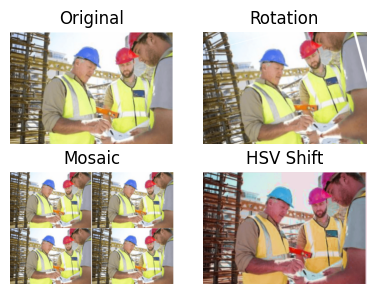

Saved as augmentation_examples_fig4.png


In [ ]:


import cv2
import matplotlib.pyplot as plt
import albumentations as A
import numpy as np

# -------------------------------
# 1. Load your original image
# -------------------------------
img = cv2.imread("/content/inbox_793761_6bca53ac8ff50857e15f708377a95397_hard_hats.png")   # <-- change this to your file
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# -------------------------------
# 2. Define augmentations
# -------------------------------
rotate_aug = A.Rotate(limit=20, p=1)
hsv_aug = A.HueSaturationValue(hue_shift_limit=20,
                               sat_shift_limit=30,
                               val_shift_limit=20, p=1)

# Make a mosaic (4 copies)
def make_mosaic(image):
    h, w, _ = image.shape
    img_resized = cv2.resize(image, (w//2, h//2))
    top = np.hstack([img_resized, img_resized])
    bottom = np.hstack([img_resized, img_resized])
    return np.vstack([top, bottom])

# -------------------------------
# 3. Apply augments
# -------------------------------
rotated = rotate_aug(image=img)["image"]
hsv_shifted = hsv_aug(image=img)["image"]
mosaic = make_mosaic(img)

# -------------------------------
# 4. Plot 2×2 grid
# -------------------------------
plt.figure(figsize=(4,3))

plt.subplot(2,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(rotated)
plt.title("Rotation")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(mosaic)
plt.title("Mosaic")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(hsv_shifted)
plt.title("HSV Shift")
plt.axis("off")

plt.tight_layout()
plt.savefig("augmentation_examples_fig4.png", dpi=300)
plt.show()

print("Saved as augmentation_examples_fig4.png")
